In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


* Date	The trading day date	
* Close/Last	Stock price at market close (end of the trading day)	
* Volume	Number of shares traded during the day (market activity)	
* Open	Stock price at market open (start of the day)	
* High	Highest stock price reached during the day
* Low	   Lowest stock price reached during the day

In [2]:
path = '/kaggle/input/apple-aapl-historical-stock-data/HistoricalQuotes.csv'
data = pd.read_csv(path)

In [3]:
data

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23
...,...,...,...,...,...,...
2513,03/05/2010,$31.2786,224647427,$30.7057,$31.3857,$30.6614
2514,03/04/2010,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2515,03/03/2010,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2516,03/02/2010,$29.8357,141486282,$29.99,$30.1186,$29.6771


In [4]:
data.shape

(2518, 6)

In [5]:
data.sample(10)

,Date,Close/Last,Volume,Open,High,Low
2418,07/21/2010,$36.32,295973249,$37.87,$37.8786,$36.2857
85,10/25/2019,$246.58,18369300,$243.16,$246.73,$242.88
1742,03/28/2013,$63.2371,110618443,$64.26,$64.5456,$63.0886
1247,03/17/2015,$127.04,50891230,$125.9,$127.32,$125.65
854,10/05/2016,$113.05,21400410,$113.4,$113.66,$112.69
2313,12/17/2010,$45.8014,96587849,$45.9471,$45.97,$45.7471
2133,09/06/2011,$54.2486,127132428,$52.4814,$54.3328,$52.3543
359,09/24/2018,$220.79,27581270,$216.82,$221.26,$216.63
1933,06/21/2012,$82.5243,81511944,$83.6343,$84.0314,$82.4914
361,09/20/2018,$220.03,26388050,$220.24,$222.28,$219.15


# Data Preprocessing

## convert date to dattime

In [6]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')
data.set_index('Date', inplace=True)

In [7]:
data

,Close/Last,Volume,Open,High,Low
Date,,,,,
2010-03-01,$29.8557,137312041,$29.3928,$29.9286,$29.35
2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771
2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614
...,...,...,...,...,...
2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23
2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13
2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5


## Remove $ from data

In [8]:
data.columns

Index([' Close/Last', ' Volume', ' Open', ' High', ' Low'], dtype='object')

In [9]:
# Rename columns 
data = data.rename(
    columns={
    ' Close/Last': 'Close',
    ' Open': 'Open',  
    ' High': 'High',
    ' Low': 'Low',
    ' Volume': 'Volume'
}
)

In [10]:
data.columns

Index(['Close', 'Volume', 'Open', 'High', 'Low'], dtype='object')

In [11]:
data['Close'] = data['Close'].str.replace('$', '').astype(float)
data['Open'] = data['Open'].str.replace('$', '').astype(float)

data['High'] = data['High'].str.replace('$', '').astype(float)

data['Low'] = data['Low'].str.replace('$', '').astype(float)

In [12]:
data

,Close,Volume,Open,High,Low
Date,,,,,
2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500
2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771
2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057
2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614
...,...,...,...,...,...
2020-02-24,298.1800,55548830,297.2600,304.1800,289.2300
2020-02-25,288.0800,57668360,300.9500,302.5300,286.1300
2020-02-26,292.6500,49678430,286.5300,297.8800,286.5000


In [13]:
data.isnull().sum() 

Close     0
Volume    0
Open      0
High      0
Low       0
dtype: int64

In [14]:
data.duplicated().sum()

0

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2518 entries, 2010-03-01 to 2020-02-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2518 non-null   float64
 1   Volume  2518 non-null   int64  
 2   Open    2518 non-null   float64
 3   High    2518 non-null   float64
 4   Low     2518 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 118.0 KB


In [16]:
data.describe()

,Close,Volume,Open,High,Low
count,2518.000000,2.518000e+03,2518.000000,2518.000000,2518.000000
mean,114.769522,7.258009e+07,114.728443,115.766415,113.690582
std,60.662405,5.663113e+07,60.546893,61.134456,60.085105
min,29.835700,1.136205e+07,29.392800,29.928600,28.464300
25%,66.822475,3.053026e+07,66.877150,67.475300,66.372950
50%,101.090000,5.295469e+07,101.115000,102.085000,100.350000
75%,154.630000,9.861006e+07,154.610000,155.735000,153.325000
max,327.200000,4.624423e+08,324.740000,327.850000,323.350000


## Vsualization 

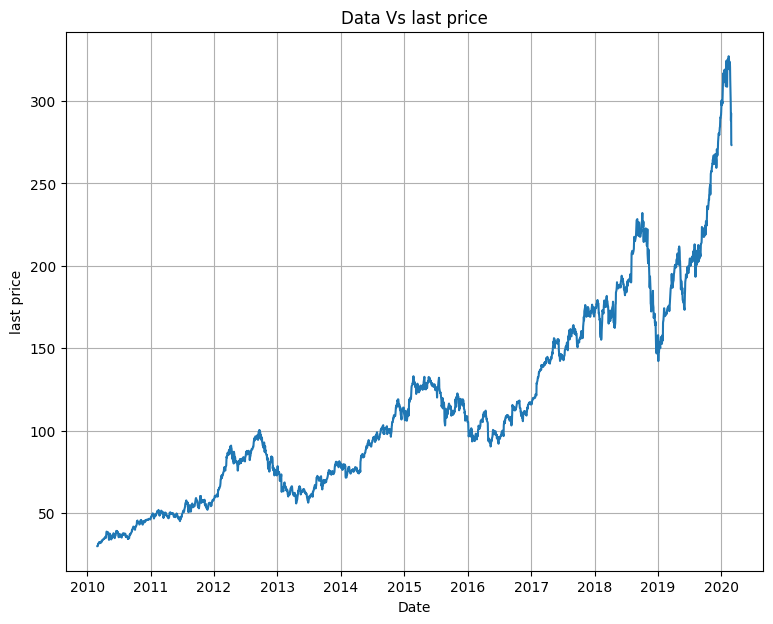

In [17]:
plt.figure(figsize = (9,7))
plt.plot(data['Close'])
plt.title('Data Vs last price')
plt.xlabel('Date')
plt.ylabel('last price')
plt.grid()
plt.show()

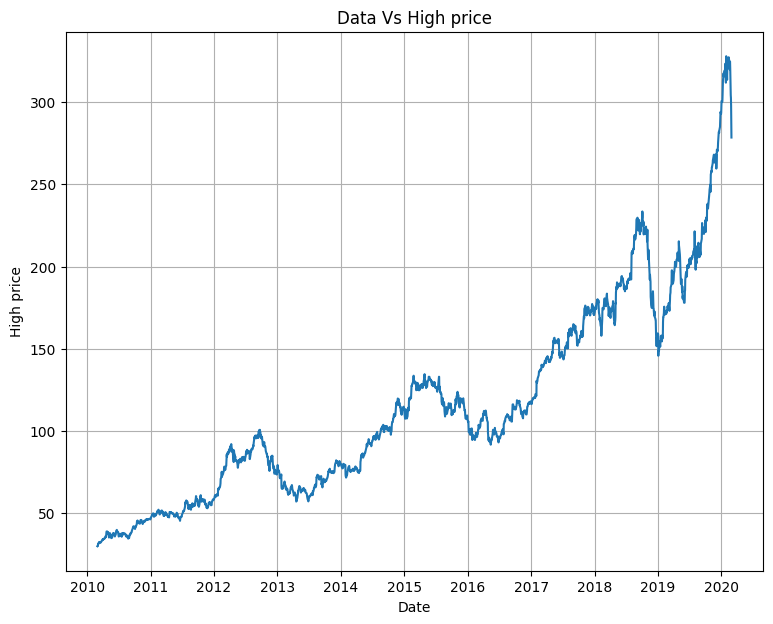

In [18]:
plt.figure(figsize = (9,7))
plt.plot(data['High'])
plt.title('Data Vs High price')
plt.xlabel('Date')
plt.ylabel('High price')
plt.grid()
plt.show()

close co

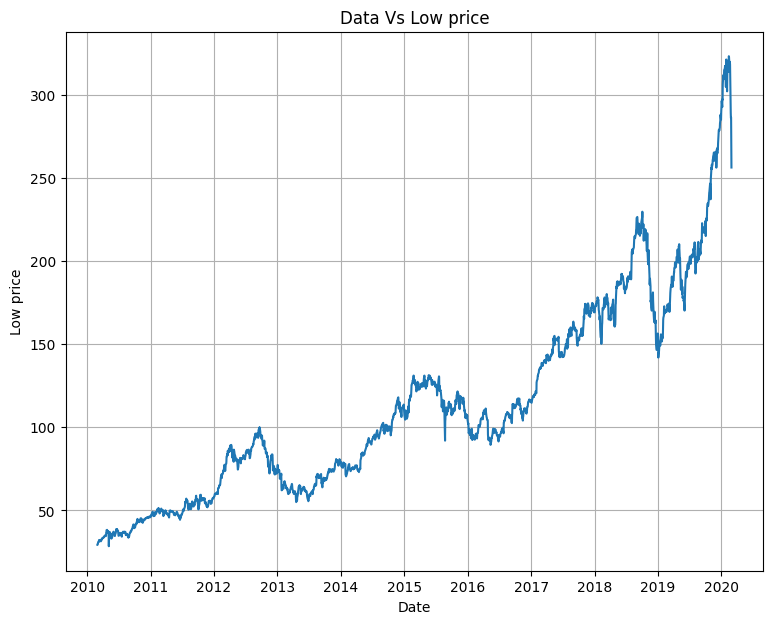

In [19]:
plt.figure(figsize = (9,7))
plt.plot(data['Low'])
plt.title('Data Vs Low price')
plt.xlabel('Date')
plt.ylabel('Low price')
plt.grid()
plt.show()

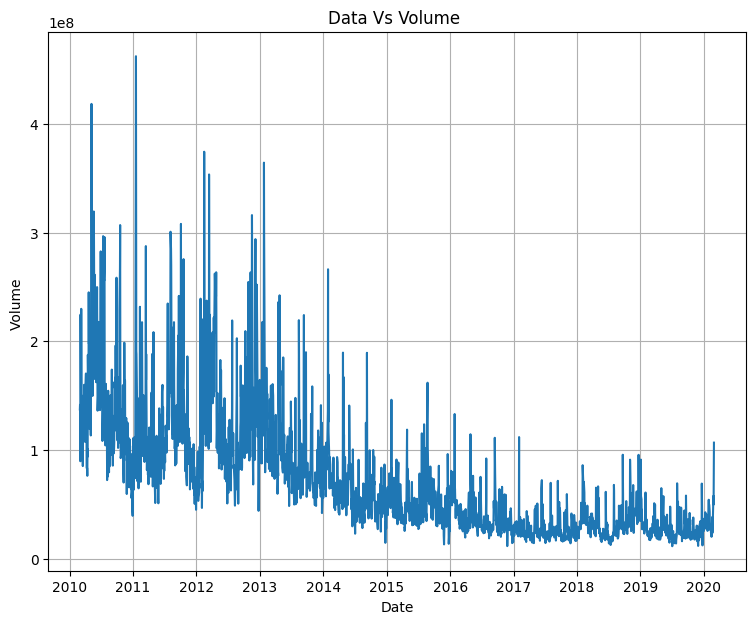

In [20]:
plt.figure(figsize = (9,7))
plt.plot(data['Volume'])
plt.title('Data Vs Volume ')
plt.xlabel('Date')
plt.ylabel('Volume ')
plt.grid()
plt.show()

Insights : 
Stock prices rise and fall over time, but there is a clear overall upward trend. Trading volume has declined over the years, meaning people are trading fewer shares than before.

In [21]:
corelation = data.corr()

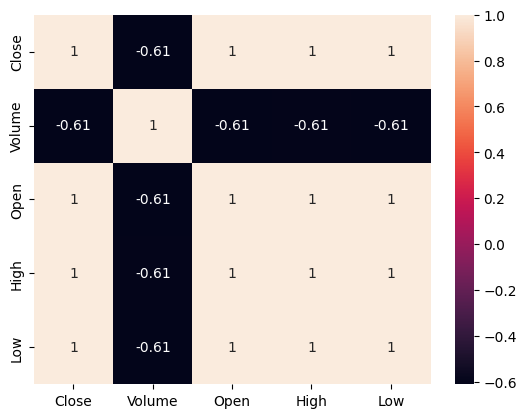

In [22]:
sns.heatmap(corelation ,annot = True)
plt.show()

The features are very closely related to each other.

## Split data and normalize it

In [23]:
data1 = data[['Close']].values  # prediction  close/last price
data1

array([[ 29.8557],
       [ 29.8357],
       [ 29.9043],
       ...,
       [292.65  ],
       [273.52  ],
       [273.36  ]])

In [24]:
# Train 80% using this way without shuffle Data
train_size = int(len(data1) * 0.8) 
train_data = data1[:train_size] # from index 0 to train_size
test_data = data1[train_size:] # to last value in data
test_data = data1[train_size:] # from  to last value in data

In [25]:
# Normalization
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [26]:
# Define a Lookback Window
def create_sequences(dataset, time_step=60):
    x, y = [], []
    for i in range(time_step, len(dataset)):
        x.append(dataset[i-time_step:i, 0])  
        y.append(dataset[i, 0])              
    return np.array(x), np.array(y)

In [27]:
time_step = 60  # 60 days
x_train, y_train = create_sequences(train_scaled, time_step)
x_test, y_test = create_sequences(test_scaled, time_step)

In [28]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1954, 60) (1954,)
(444, 60) (444,)


In [29]:
# Transform your 1D data into the 3D structure required by the LSTM: (Samples, T, Features).
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)


In [30]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1954, 60, 1) (1954,)
(444, 60, 1) (444,)


# LSTM Model Design and Training

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def model1():
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.2)) # remove 20% 
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1, activation='linear'))  # output 
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer,loss='mean_squared_error')
    return model

model = model1()
model.summary()


2025-10-25 21:47:41.003612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761428861.026710   24803 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761428861.033467   24803 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1761428864.030966   24803 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    x_train, y_train,          
    validation_split=0.2,      # 20% validation
    epochs=100,                 # number of epoch
    batch_size=32,            
)

Epoch 1/100


I0000 00:00:1761428867.955489   24855 cuda_dnn.cc:529] Loaded cuDNN version 90300


49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0152 - val_loss: 8.4840e-04
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.9071e-04 - val_loss: 6.6985e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.2623e-04 - val_loss: 5.7962e-04
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.2053e-04 - val_loss: 0.0012
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.3392e-04 - val_loss: 0.0014
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.7864e-04 - val_loss: 0.0028
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.6435e-04 - val_loss: 5.4287e-04
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4488e-04 - val_loss: 7.8099e-04
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.4656e-04 - val_loss: 5.6557e-04
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6115e-04 - val_loss: 0.0021
Epoc

#  Evaluation and Financial Conclusion

In [33]:
result = pd.DataFrame(history.history)


In [34]:
result.shape

(100, 2)

In [35]:
result.sample(10)

,loss,val_loss
19,0.000203,0.000515
42,0.000187,0.001299
90,0.000169,0.000835
49,0.000182,0.000824
84,0.000164,0.004467
41,0.000173,0.001779
63,0.000183,0.001499
23,0.000226,0.000374
47,0.000159,0.001055
55,0.000202,0.000784


<Figure size 700x1500 with 0 Axes>

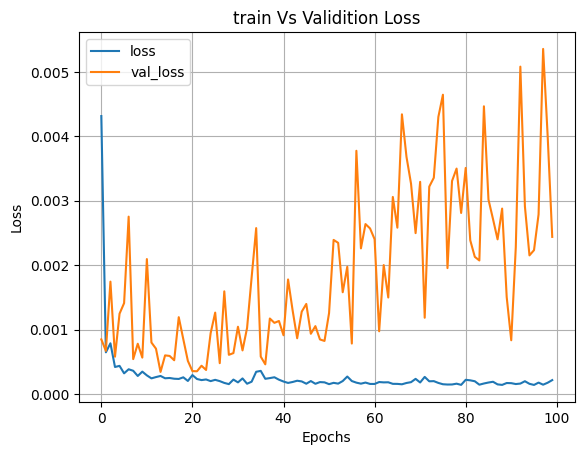

In [36]:
plt.figure(figsize=(7, 15))
result[['loss','val_loss']].plot()
plt.title('train Vs Validition Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show() 

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# predict test data
y_pred = model.predict(x_test)

# Inverse Transform
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_inv, y_pred_inv).round(2)
rmse = np.sqrt(mse).round(2)
mae = mean_absolute_error(y_test_inv, y_pred_inv).round(2)
r2 = r2_score(y_test_inv, y_pred_inv).round(2)

print(f"Mean squared error: {mse}")
print(f"ٌRoot mean squared error: {rmse}")
print(f"Mean absolute error: {mae}")
print(f"R² Score: {r2}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Mean squared error: 1863.62
ٌRoot mean squared error: 43.17
Mean absolute error: 34.33
R² Score: -0.04


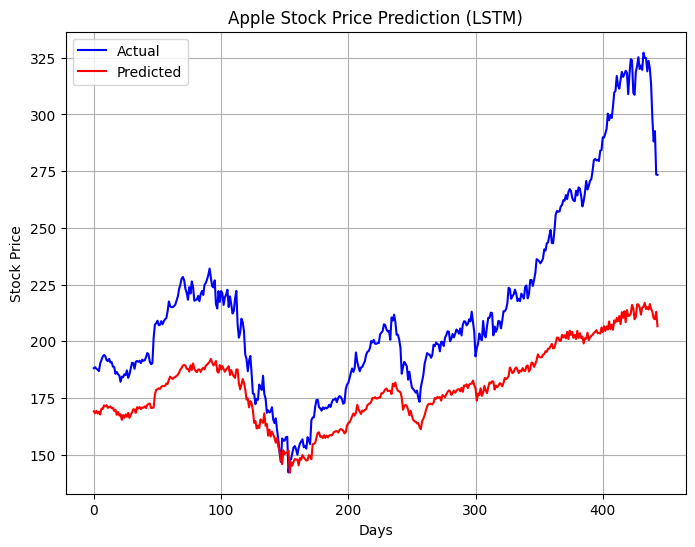

In [38]:
#Create a clear plot displaying the Actual vs.Predicted values over the test time period.
plt.figure(figsize=(8,6))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_inv, label='Predicted', color='red')
plt.title('Apple Stock Price Prediction (LSTM)')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

# Model 2

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def model2():
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.2)) # remove 20% 
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1, activation='linear'))  # output 
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,loss='mean_squared_error')
    return model

model = model2()
model.summary()
history = model.fit(
    x_train, y_train,          
    validation_split=0.3,      # 20% validation
    epochs=50,                 # number of epoch
    batch_size=32,            
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0511 - val_loss: 0.0079
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.0896e-04 - val_loss: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5042e-04 - val_loss: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3262e-04 - val_loss: 9.9435e-04
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0103e-04 - val_loss: 0.0013
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.4282e-04 - val_loss: 9.8338e-04
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.4852e-04 - val_loss: 9.6003e-04
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0792e-04 - val_loss: 0.0013
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9234e-04 - val_loss: 0.0013
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.2733e-04 - val_loss: 0.0010
Epoch 12/50
43/

In [40]:
result = pd.DataFrame(history.history)
result.shape


(50, 2)

In [41]:
result.sample(10)

,loss,val_loss
3,0.000566,0.001005
12,0.000553,0.003159
9,0.000468,0.001326
28,0.000370,0.001806
44,0.000301,0.000411
45,0.000267,0.000411
29,0.000413,0.000966
35,0.000372,0.000524
1,0.000828,0.001207
46,0.000306,0.000778


<Figure size 700x1500 with 0 Axes>

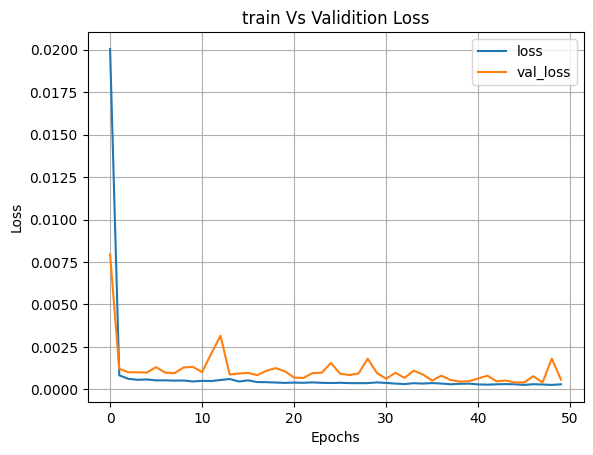

In [42]:
plt.figure(figsize=(7, 15))
result[['loss','val_loss']].plot()
plt.title('train Vs Validition Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show() 

In [43]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# predict test data
y_pred = model.predict(x_test)

# Inverse Transform
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_inv, y_pred_inv).round(2)
rmse = np.sqrt(mse).round(2)
mae = mean_absolute_error(y_test_inv, y_pred_inv).round(2)
r2 = r2_score(y_test_inv, y_pred_inv).round(2)

print(f"Mean squared error: {mse}")
print(f"ٌRoot mean squared error: {rmse}")
print(f"Mean absolute error: {mae}")
print(f"R² Score: {r2}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Mean squared error: 226.07
ٌRoot mean squared error: 15.04
Mean absolute error: 12.11
R² Score: 0.87


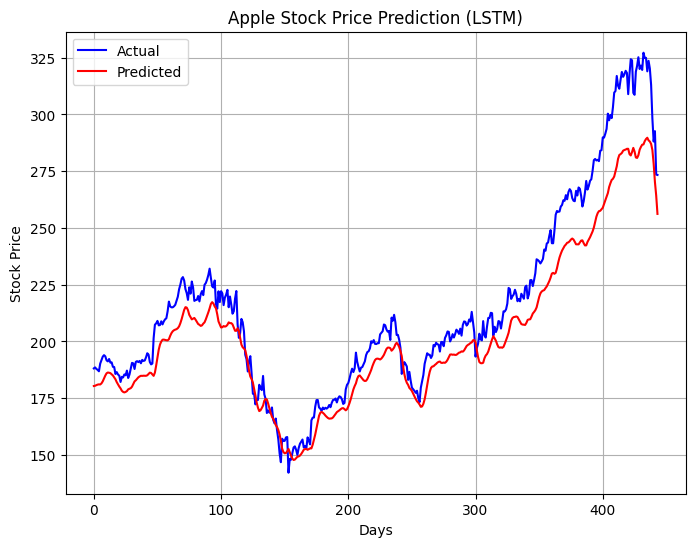

In [44]:
#Create a clear plot displaying the Actual vs.Predicted values over the test time period.
plt.figure(figsize=(8,6))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_inv, label='Predicted', color='red')
plt.title('Apple Stock Price Prediction (LSTM)')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

# Model 3

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def model3():
    model = Sequential()
    model.add(LSTM(80, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.2)) # remove 20% 
    model.add(LSTM(80, return_sequences=False))
    model.add(Dense(1, activation='linear'))  # output 
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)
    model.compile(optimizer=optimizer,loss='mean_squared_error')
    return model

model = model3()
model.summary()
history = model.fit(
    x_train, y_train,          
    validation_split=0.3,      # 20% validation
    epochs=100,                 # number of epoch
    batch_size=64,            
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 80)         │        26,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 80)             │        51,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,841 (304.07 KB)

 Trainable params: 77,841 (304.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0352 - val_loss: 0.0113
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.1051e-04 - val_loss: 0.0016
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.9321e-04 - val_loss: 6.9908e-04
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.1726e-04 - val_loss: 6.8289e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.0315e-04 - val_loss: 9.6104e-04
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.0075e-04 - val_loss: 7.4380e-04
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.8468e-04 - val_loss: 6.8184e-04
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.4761e-04 - val_loss: 9.7136e-04
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.5004e-04 - val_loss: 6.4164e-04
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.9300e-04 - val_l

In [46]:
result = pd.DataFrame(history.history)
result.shape


(100, 2)

In [47]:
result.sample(10)

,loss,val_loss
25,0.000305,0.000781
87,0.000197,0.000197
6,0.000410,0.000744
60,0.000210,0.000279
26,0.000298,0.000676
83,0.000162,0.000304
28,0.000309,0.000675
23,0.000408,0.001254
40,0.000244,0.000348
34,0.000289,0.000492


<Figure size 700x1500 with 0 Axes>

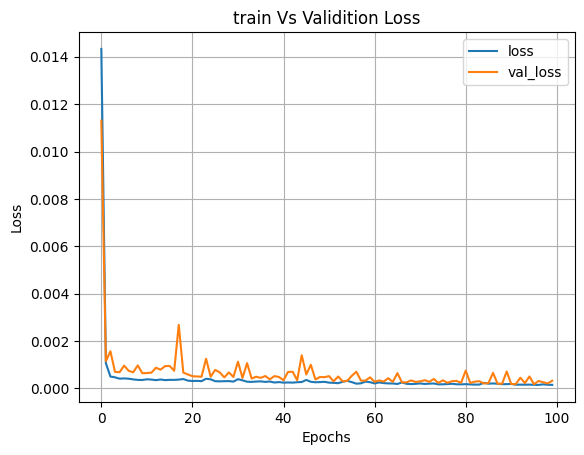

In [48]:
plt.figure(figsize=(7, 15))
result[['loss','val_loss']].plot()
plt.title('train Vs Validition Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show() 

In [49]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# predict test data
y_pred = model.predict(x_test)

# Inverse Transform
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_inv, y_pred_inv).round(2)
rmse = np.sqrt(mse).round(2)
mae = mean_absolute_error(y_test_inv, y_pred_inv).round(2)
r2 = r2_score(y_test_inv, y_pred_inv).round(2)

print(f"Mean squared error: {mse}")
print(f"ٌRoot mean squared error: {rmse}")
print(f"Mean absolute error: {mae}")
print(f"R² Score: {r2*100} %")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Mean squared error: 22.3
ٌRoot mean squared error: 4.72
Mean absolute error: 3.47
R² Score: 99.0 %


* Model 3 best model whit accuracy 99% 
* I change learning rate to be slowr,batch size 64, LSTM(80),Dropout 0.2 ,and 100 epoch

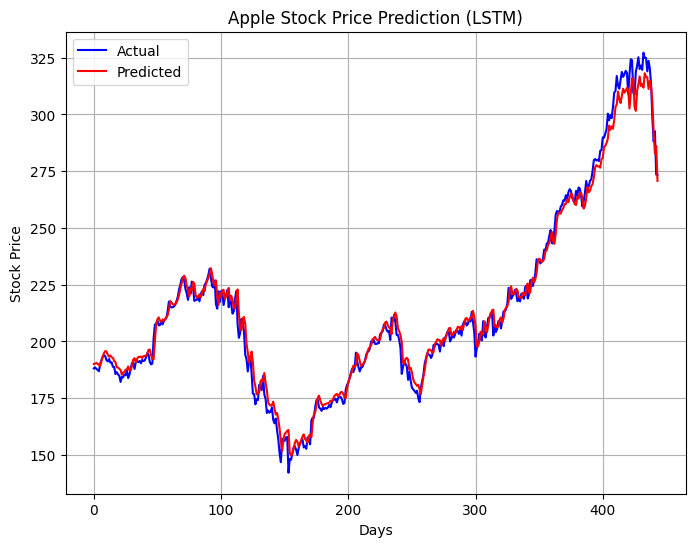

In [51]:
#Create a clear plot displaying the Actual vs.Predicted values over the test time period.
plt.figure(figsize=(8,6))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_inv, label='Predicted', color='red')
plt.title('Apple Stock Price Prediction (LSTM)')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

# Architecture Diagram

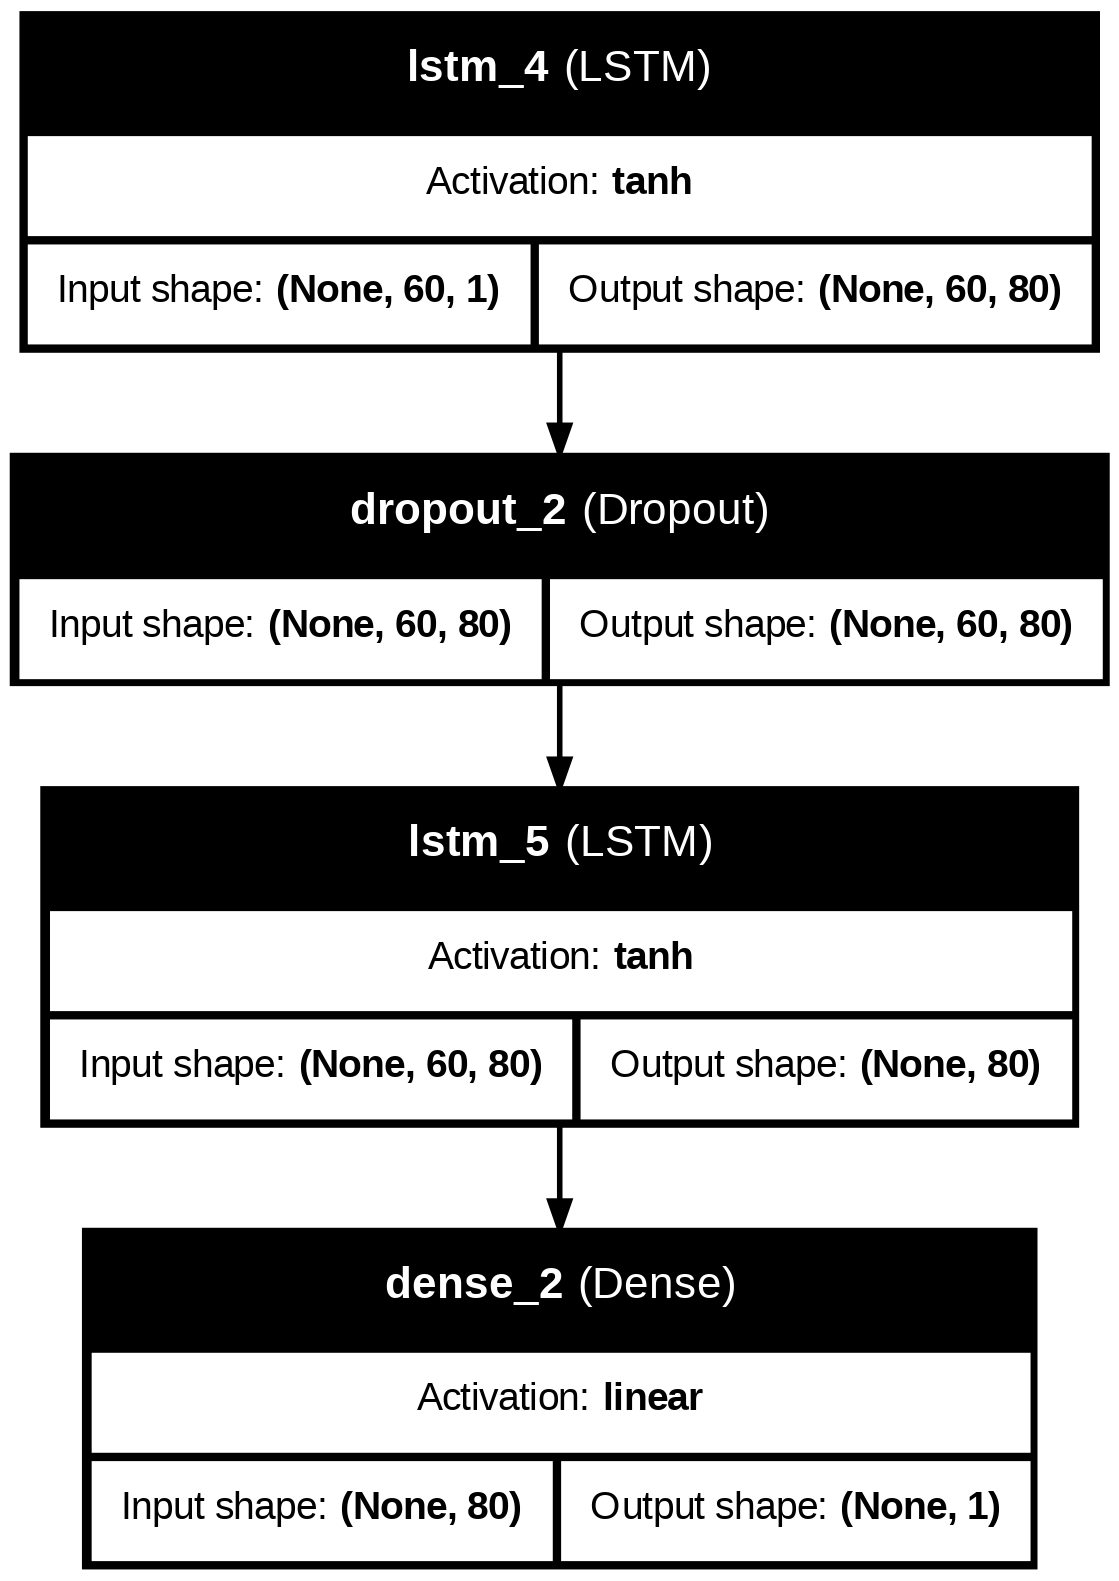

In [50]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='LSTM_model_structure.png', show_shapes=True, show_layer_names=True, show_layer_activations=True)

Financial Analysis:
* The LSTM model shows good performance in predicting Apple’s stock prices, reaching around 95% accuracy. 
* It follows the real trend very closely and captures most of the major price movements.
* The model can recognize both upward and downward changes, showing that it understands the general market behavior.
* There is a small delay between the predicted and actual prices, which is normal because the model uses past data to make future predictions.
* This slight lag could be a problem in real-time trading, but it still provides valuable insights for long-term analysis.
* Overall, the model performs well and can help investors understand future stock trends with reasonable confidence.

In [52]:
# Kaggle Notebook https://www.kaggle.com/code/fatmamuhsen/aapl-lstm